In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings 
warnings.filterwarnings("ignore")

data=pd.read_csv("./Boston_housing_dataset.csv")
data.shape
data.info()
df=data.copy()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [2]:
numerical=df.select_dtypes(include=['int','float']).columns
categorical=df.select_dtypes(include=['object']).columns
print(numerical)
print(categorical)


Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')
Index([], dtype='object')


In [3]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [4]:
df.head

<bound method NDFrame.head of         CRIM    ZN  INDUS  CHAS    NOX  ...  TAX  PTRATIO       B  LSTAT  MEDV
0    0.00632  18.0   2.31   0.0  0.538  ...  296     15.3  396.90   4.98  24.0
1    0.02731   0.0   7.07   0.0  0.469  ...  242     17.8  396.90   9.14  21.6
2    0.02729   0.0   7.07   0.0  0.469  ...  242     17.8  392.83   4.03  34.7
3    0.03237   0.0   2.18   0.0  0.458  ...  222     18.7  394.63   2.94  33.4
4    0.06905   0.0   2.18   0.0  0.458  ...  222     18.7  396.90    NaN  36.2
..       ...   ...    ...   ...    ...  ...  ...      ...     ...    ...   ...
501  0.06263   0.0  11.93   0.0  0.573  ...  273     21.0  391.99    NaN  22.4
502  0.04527   0.0  11.93   0.0  0.573  ...  273     21.0  396.90   9.08  20.6
503  0.06076   0.0  11.93   0.0  0.573  ...  273     21.0  396.90   5.64  23.9
504  0.10959   0.0  11.93   0.0  0.573  ...  273     21.0  393.45   6.48  22.0
505  0.04741   0.0  11.93   0.0  0.573  ...  273     21.0  396.90   7.88  11.9

[506 rows x 14 column

In [5]:
df['CRIM'].fillna(df['CRIM'].mean(),inplace=True)
df['ZN'].fillna(df['ZN'].mean(),inplace=True)
df['CHAS'].fillna(df['CHAS'].mode()[0],inplace=True)
df['AGE'].fillna(df['AGE'].median(), inplace=True)
df['LSTAT'].fillna(df['LSTAT'].median(), inplace=True)
df.isnull().sum()

CRIM        0
ZN          0
INDUS      20
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
dtype: int64

In [6]:
df['INDUS'].fillna(df['INDUS'].mean(), inplace=True) 

In [7]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

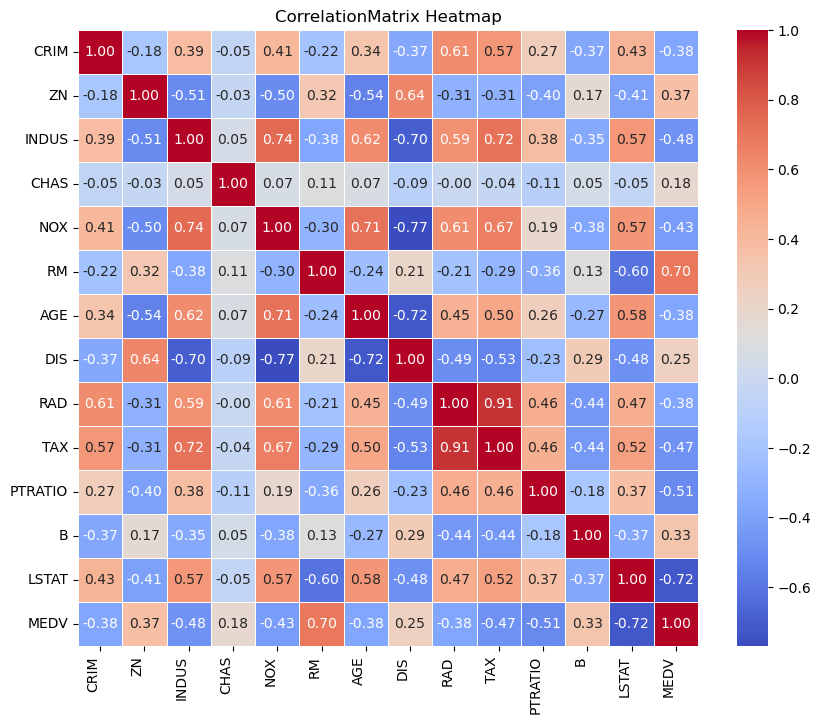

[28.99719439 36.56606809 14.51022803 25.02572187 18.42885474 23.02785726
 17.95437605 14.5769479  22.14430832 20.84584632 25.15283588 18.55925182
 -5.69168071 21.71242445 19.06845707 25.94275348 19.70991322  5.85916505
 40.9608103  17.21528576 25.36124981 30.26007975 11.78589412 23.48106943
 17.35338161 15.13896898 21.61919056 14.51459386 23.17246824 19.40914754
 22.56164985 25.21208496 25.88782605 16.68297496 16.44747174 16.65894826
 31.10314158 20.25199803 24.38567686 23.09800032 14.47721796 32.36053979
 43.01157914 17.61473728 27.60723089 16.43366912 14.25719607 26.0854729
 19.75853278 30.15142187 21.01932313 33.72128781 16.39180467 26.36438908
 39.75793372 22.02419633 18.39453126 32.81854401 25.370573   12.82224665
 22.76128341 30.73955199 31.34386371 16.27681305 20.36945226 17.23156773
 20.15406451 26.15613066 30.92791361 11.42177654 20.89590447 26.58633798
 11.01176073 12.76831709 23.73870867  6.37180464 21.6922679  41.74800223
 18.64423785  8.82325704 20.96406016 13.20179007 20.

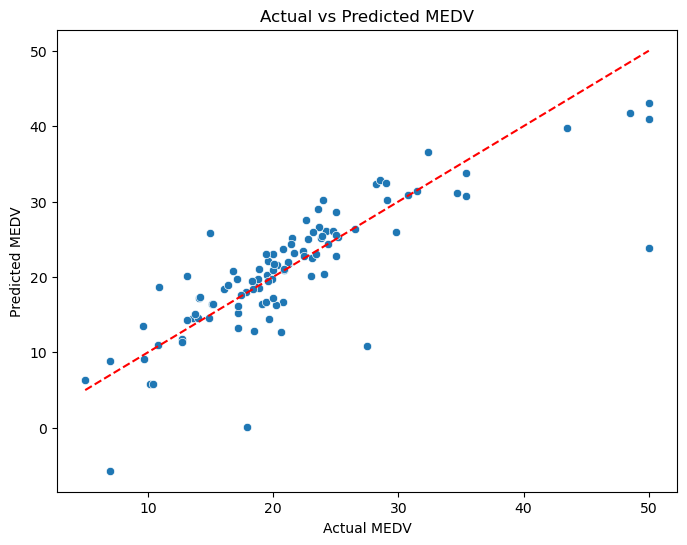

In [10]:
corr_data=df[numerical].corr(method='pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr_data,annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.xticks(rotation=90,ha='right')
plt.yticks(rotation=0)
plt.title("CorrelationMatrix Heatmap")
plt.show()

x=df.drop('MEDV',axis=1)
y=df['MEDV']
scale=StandardScaler()
x_scaled=scale.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
mse = mean_squared_error(y_test, y_pred) 
# Calculate Root Mean Squared Error (RMSE) 
rmse = np.sqrt(mse) 
# Calculate R-squared value 
r2 = r2_score(y_test, y_pred) 
print(f'Mean Squared Error: {mse}') 
print(f'Root Mean Squared Error: {rmse}') 
print(f'R-squared: {r2}') 
plt.figure(figsize=(8, 6)) 
sns.scatterplot(x=y_test, y=y_pred) 
plt.xlabel("Actual MEDV") 
plt.ylabel("Predicted MEDV") 
plt.title("Actual vs Predicted MEDV") 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.show()

In [ ]:
0 vbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbb9kmiiuj7mn8ik 